In [22]:
import seaborn as sns
from scipy.stats import mannwhitneyu
import matplotlib.pylab as pylab
import pandas as pd
import pickle
import json
import random
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family'   : 'Arial', 
    'mathtext.fontset': 'custom',   
    'mathtext.rm'     : 'Arial', 
    'mathtext.it'     : 'Arial:italic',
    'mathtext.bf'     : 'Arial:bold',
})
glob_size = 5.5
pylab.rcParams.update({
    'font.family': 'Arial',
    'font.size': glob_size,   
    'axes.titlesize': glob_size,      
    'axes.labelsize': glob_size,             
    'xtick.labelsize': glob_size,        
    'ytick.labelsize': glob_size,          
    'legend.fontsize': glob_size,           
    'figure.titlesize': glob_size,        
})
plt.rcParams['figure.dpi'] = 200

In [23]:
# Load data
dataset_gene_mut_df = pd.read_csv('./data/gene.variant_record.gnomad_RGCME.csv')
af_bins = ['<1e-5', '1e-5~1e-4', '1e-4~1e-3', '1e-3~1e-2', '1e-2<']

In [24]:
# Calculate dN/dS
plot_df_lst = []

for is_cRDHGs, gene_group_name in zip(
    [True, False],
    ['cRDHGs', 'Other genes']
):

    sub_df = dataset_gene_mut_df[dataset_gene_mut_df['is_cRDHGs'] == is_cRDHGs].copy()

    ssite = sub_df['ssite'].sum()
    non_nsite = sub_df['non_nsite'].sum()
    mis_nsite = sub_df['mis_nsite'].sum()

    for dataset in ['gnomAD', 'RGC-ME']:

        for af_bin in af_bins:

            mis_symbol = f'{dataset}_mis_{af_bin}'
            non_symbol = f'{dataset}_stopgain_{af_bin}'
            syn_symbol = f'{dataset}_syn_{af_bin}'

            mis_dnds = (sub_df[mis_symbol].sum() / mis_nsite) / (sub_df[syn_symbol].sum() / ssite)
            non_dnds = (sub_df[non_symbol].sum() / non_nsite) / (sub_df[syn_symbol].sum() / ssite)

            plot_df_lst.append({
                'gene': gene_group_name,
                'dataset': dataset,
                'type': 'missense',
                'AF bin': af_bin,
                'dN/dS': mis_dnds,
                'count': sub_df[mis_symbol].sum()
            })
            plot_df_lst.append({
                'gene': gene_group_name,
                'dataset': dataset,
                'type': 'nonsense',
                'AF bin': af_bin,
                'dN/dS': non_dnds,
                'count': sub_df[non_symbol].sum()
            })

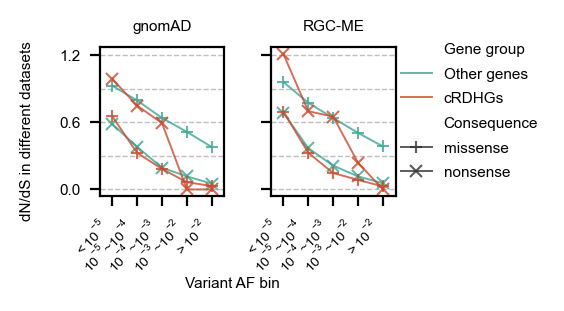

In [27]:
plot_df = pd.DataFrame(plot_df_lst)
plot_df['gene'] = pd.Categorical(
    plot_df['gene'],
    categories=['Other genes', 'cRDHGs'],
    ordered=True,
)

plot_df = plot_df[plot_df['dataset'] != 'UKB']
y_breaks = np.linspace(
    plot_df['dN/dS'].min(),
    plot_df['dN/dS'].max(),
    3
)

af_bins = ['<1e-5', '1e-5~1e-4', '1e-4~1e-3', '1e-3~1e-2', '1e-2<']
pretty_af_labels = {
    '<1e-5'    : r'$<10^{-5}$',
    '1e-5~1e-4': r'$10^{-5}$~$10^{-4}$',
    '1e-4~1e-3': r'$10^{-4}$~$10^{-3}$',
    '1e-3~1e-2': r'$10^{-3}$~$10^{-2}$',
    '1e-2<'    : r'$>10^{-2}$',
}

fig, axes = plt.subplots(1, 2, figsize=(2, 1.6), sharey=True)

for idx, dataset in enumerate(plot_df['dataset'].unique()):
    sub_df = plot_df[plot_df['dataset'] == dataset]
    # Rename columns for easier plotting
    sub_df.columns = sub_df.columns.map(
        lambda x: {
            'gene': 'Gene group',
            'type': 'Consequence',
        }.get(x, x)
    )

    ax = axes[idx]
    sns.lineplot(
        data=sub_df, 
        x='AF bin', 
        y='dN/dS', 
        hue='Gene group', 
        style='Consequence', 
        markers={'missense': '+', 'nonsense': 'x'}, 
        dashes=False, 
        ax=ax,
        palette=['#3BA595', '#CA4A2E'],
        linewidth=0.7,
        markersize=4,
        markeredgecolor='auto',
        alpha=0.8
    )
    
    ax.set_xticks(range(len(af_bins)))
    ax.set_xticklabels([pretty_af_labels[bin] for bin in af_bins], ha='right')
    # x axis rotation
    ax.tick_params(axis='x', rotation=45, labelsize=5)
    ax.set_yticks([0, 0.6, 1.2])
    ax.set_title(dataset)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xlim(-0.5, len(af_bins) - 0.5)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend_.remove()

    for y in np.arange(0, 1.5, 0.3):
        ax.axhline(y=y, color='grey', linestyle='--', linewidth=0.5, alpha=0.5, zorder=-1)

fig.supxlabel('Variant AF bin', fontsize=5.5, y=0.1, x=0.55)
fig.supylabel('dN/dS in different datasets', fontsize=5.5, y=0.6)
fig.legend(
    handles, 
    labels, 
    loc='upper right', 
    ncol=1, 
    alignment='left',
    fontsize=5.5, 
    title_fontsize=5.5,
    frameon=False,
    bbox_to_anchor=(1.35, 0.92),
    labelspacing=0.7
)
plt.tight_layout()